In [34]:
import pySPM
print(pySPM.__version__)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

import os
from IPython import display

I = pySPM.ITM('LiNbO3_position 2 BA positive depth.itm')
from IPython import display
I.show_values()


0.6.2


/home/cbed/hannes/Dataanalysis_Tof_SIMs/henv/lib/python3.10/site-packages/pySPM/ITM.py:149: UserWarning: Failed to get sf,k0, find alternative
  self.sf, self.k0 = self.get_mass_cal()


In [24]:
import shift as sh
import matplotlib.pyplot as plt
import numpy as np
import glob
import os



In [25]:
data = sh.importdata('Lil10')
data = sh.cutting(data, 1)
dmap = data[0]  
dmap = dmap / dmap.mean(axis = 0) -1
positivemap = np.zeros((256, 256))
nmap = np.zeros((256, 256))
for i in range(256):
    for j in range(256):
        if dmap[i][j]> 0 :
            positivemap[i][j]=1
        elif dmap[i][j]< 0 :
            nmap[i][j]=1

In [26]:

pattern = os.path.join(os.getcwd(), '*10')
files = glob.glob(pattern)
folders = [os.path.basename(f) for f in glob.glob(pattern) if os.path.isdir(f)]

dataa = [[]for i in folders]
dataa2 = [[]for i in folders]
for i in range(len(folders)):
    data = sh.importdata(folders[i])
    data2 = np.multiply(data, nmap)
    data1 = np.multiply(data, positivemap)
    dataa[i] = data1.sum(axis=1).sum(axis=1)
    dataa2[i] = data2.sum(axis=1).sum(axis=1)

[247. 221. 225. ... 245. 247. 236.] [206. 206. 232. ... 248. 241. 197.]


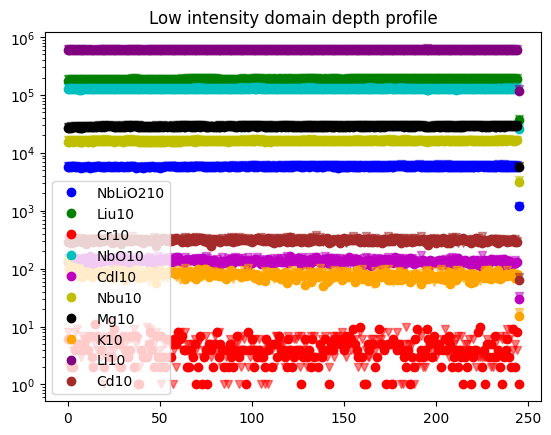

In [27]:
print(dataa2[0], dataa[0])
x = np.arange(0,len(dataa[0]))
plt.plot
fig, ax = plt.subplots()
for i in (0,1,2,3,4,5,6,7,8,9):
    window_size = 25
    data1 = dataa[i]
    data2 = dataa2[i]

    data1 = [np.sum(data1[i:i + window_size]) for i in range(0, len(data1), window_size)]
    data2 = [np.sum(data2[i:i + window_size]) for i in range(0, len(data2), window_size)]
    x = np.arange(0,len(dataa[0])/window_size)
    color = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'lime', 'teal', 'lavender', 'salmon', 'maroon']
    ax.plot(x, data1, linestyle = 'None', marker = 'o', label = folders[i], color = color[i])
    ax.plot(x, data2, linestyle = 'None', marker = 'v', color = color[i], alpha=0.5 )
    ax.set_yscale('log')
    #ax.set_title('High intensity domain depth profile')
    ax.set_title('Low intensity domain depth profile')
plt.legend()


['NbLiO210', 'Liu10', 'Cr10', 'NbO10', 'Cdl10', 'Nbu10', 'Mg10', 'K10', 'Li10', 'Cd10', 'O10', 'Cdu10', 'Li_2O_210', 'Nal10', 'Nb10', 'Na10', 'NbLiO10', 'Nbl10', 'CdO10', 'Bi10', 'Lil10', 'Nau10']


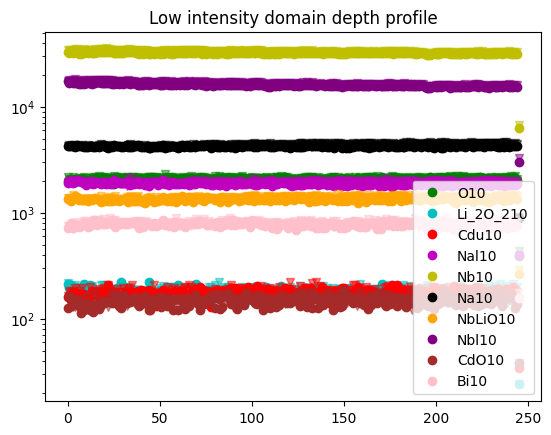

In [28]:
print(folders)

plt.plot
fig, ax = plt.subplots()
for i in (10,12,11,13,14,15,16,17,18,19):
    window_size = 25
    data1 = dataa[i]
    data2 = dataa2[i]

    data1 = [np.sum(data1[i:i + window_size]) for i in range(0, len(data1), window_size)]
    data2 = [np.sum(data2[i:i + window_size]) for i in range(0, len(data2), window_size)]
    x = np.arange(0,len(dataa[0])/window_size)
    color = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'lime', 'teal', 'lavender', 'salmon', 'maroon']
    ax.plot(x, data1, linestyle = 'None', marker = 'o', label = folders[i], color = color[i-9])
    ax.plot(x, data2, linestyle = 'None', marker = 'v', color = color[i-9], alpha=0.5 )
    ax.set_yscale('log')
    #ax.set_title('High intensity domain depth profile')
    ax.set_title('Low intensity domain depth profile')
plt.legend()


[247. 221. 225. ... 245. 247. 236.] [206. 206. 232. ... 248. 241. 197.]


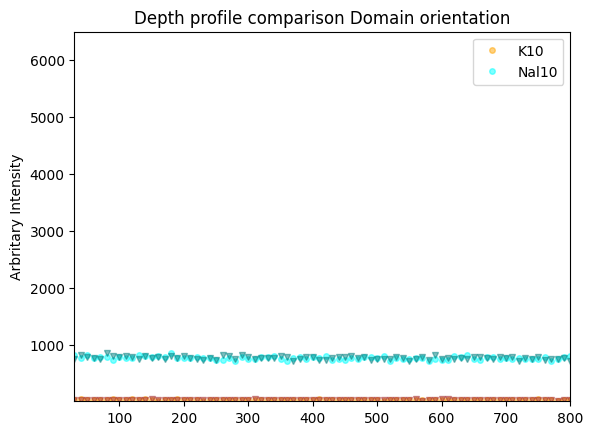

In [29]:
print(dataa2[0], dataa[0])

plt.plot
fig, ax = plt.subplots()
for i in (7,13):
    window_size = 10
    data1 = dataa[i]
    data2 = dataa2[i]

    data1 = [np.sum(data1[i:i + window_size]) for i in range(0, len(data1), window_size)]
    data2 = [np.sum(data2[i:i + window_size]) for i in range(0, len(data2), window_size)]
    x = np.arange(0,len(dataa[0])/window_size)* window_size 
    color = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'lime', 'teal', 'lavender', 'salmon', 'maroon']
    ax.plot(x, data1, linestyle = 'None', marker = 'o', label = folders[i], color = color[i], markersize = 4, alpha=0.5)
    ax.plot(x, data2, linestyle = 'None', marker = 'v', color = color[i+2], alpha=0.5, markersize = 4 )
    #ax.set_title('High intensity domain depth profile')
    ax.set_title('Depth profile comparison Domain orientation')
    ax.set_ylim(10,6500)
    ax.set_xlim(30, 80 * window_size)
    ax.set_ylabel('Arbritary Intensity')
    
plt.legend()

[247. 221. 225. ... 245. 247. 236.] [206. 206. 232. ... 248. 241. 197.]


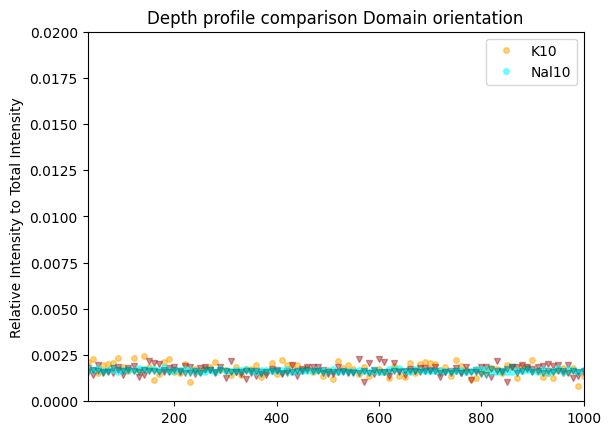

In [30]:
print(dataa2[0], dataa[0])

plt.plot
fig, ax = plt.subplots()
for i in (7,13):
    window_size = 10
    data1 = dataa[i]
    data2 = dataa2[i]

    data1 = [np.sum(data1[i:i + window_size])/np.sum(data1) for i in range(0, len(data1), window_size)]
    data2 = [np.sum(data2[i:i + window_size])/np.sum(data2) for i in range(0, len(data2), window_size)]
    x = np.arange(0,len(dataa[0])/window_size)* window_size 
    color = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'lime', 'teal', 'lavender', 'salmon', 'maroon']
    ax.plot(x, data1, linestyle = 'None', marker = 'o', label = folders[i], color = color[i], markersize = 4, alpha=0.5)
    ax.plot(x, data2, linestyle = 'None', marker = 'v', color = color[i+2], alpha=0.5, markersize = 4 )
    #ax.set_title('High intensity domain depth profile')
    ax.set_title('Depth profile comparison Domain orientation')
    ax.set_xlim(30, 100 * window_size)
    ax.set_ylim(0,0.02)
    ax.set_ylabel('Relative Intensity to Total Intensity')
    
plt.legend()

['NbLiO210', 'Liu10', 'Cr10', 'NbO10', 'Cdl10', 'Nbu10', 'Mg10', 'K10', 'Li10', 'Cd10', 'O10', 'Cdu10', 'Li_2O_210', 'Nal10', 'Nb10', 'Na10', 'NbLiO10', 'Nbl10', 'CdO10', 'Bi10', 'Lil10', 'Nau10']


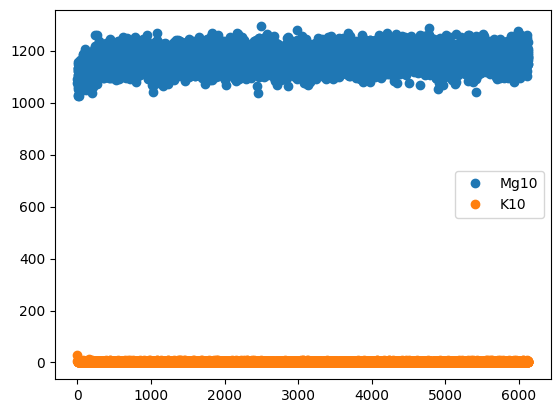

In [165]:
print(folders)
x = np.arange(0,len(dataa[0]))
plt.plot
fig, ax = plt.subplots()
for i in (6,7):
    ax.plot(x, dataa[i], linestyle = 'None', marker = 'o', label = folders[i])
plt.legend()
